# 基于歌曲歌词署名信息的音乐创作者结构分析

## 数据来源与研究目标

本次分析使用爬虫从酷我音乐获取的歌曲数据，共包含 2214 首歌曲。原始字段包括歌曲名称、演唱者、专辑、时长和歌词等信息。

由于部分歌词开头包含作词人、作曲人等署名信息，本文尝试从歌词文本中提取创作者姓名，并在此基础上研究以下三个问题：

1. 歌曲创作资源是否集中在少数头部作词人和作曲人手中；
2. 不同歌手参与自身歌曲作词、作曲的程度是否存在差异；
3. 歌手与特定创作者之间是否存在稳定的长期合作关系。

需要说明的是，分析结果仅反映本次爬取并成功识别创作者信息的歌曲样本，不能直接代表平台全部歌曲或整个音乐行业。

下面的内容详细介绍了从数据获取到处理到画图分析得出结论的全过程

## 第一板块：创作资源集中度分析

In [26]:
import json
import re
import pandas as pd
import numpy as np

from pathlib import Path

input_path = Path("data") / "songs_stage3_lyrics.json"

with open(input_path, "r", encoding="utf-8") as f:
    songs_data = json.load(f)

songs = pd.DataFrame(songs_data)

print("歌曲总数：", len(songs))
print(songs.columns.tolist())

歌曲总数： 2214
['song_order', 'song_name', 'keyword', 'artist_name', 'artist_id', 'song_id', 'musicrid', 'album', 'duration', 'image_url', 'source_url', 'lyrics']


#### 作词、作曲信息提取

歌曲数据中没有独立的作词人和作曲人字段，但部分歌词开头包含创作者署名，例如：

- `作词：方文山`
- `作曲：周杰伦`
- `Lyrics by: Michael Jackson`
- `Composed by: Michael Jackson`

因此，本文使用正则表达式匹配歌词开头的署名信息。考虑到创作者信息通常位于歌词前部，程序只检查每首歌词的前 10 行，并分别提取作词人和作曲人的原始字符串。

对于无法匹配的歌曲，相应字段记为空值。后续分析仅使用成功识别出对应创作者信息的歌曲。

In [27]:
def extract_creators(lyrics):
    """
    从一首歌曲的歌词中提取作词人和作曲人。

    返回格式：
    {
        "lyricist_raw": 作词人原始字符串,
        "composer_raw": 作曲人原始字符串
    }

    找不到时，对应字段为 None。
    """
    result={
        "lyricist_raw":None,
        "composer_raw":None,
    }
    combined_pattern=re.compile(
        r"^(?:词曲|作词作曲|作词\s*/\s*作曲|词\s*/\s*曲)\s*[:：]\s*(.+)$",
        flags=re.IGNORECASE,
    )
    lyricist_pattern = re.compile(
        r"^(?:(?:作词人?|填词|词)\s*(?:Lyricist)?|Lyrics\s+by)\s*[:：]\s*(.+)",
        flags=re.IGNORECASE,
    )
    composer_pattern = re.compile(
        r"^(?:(?:作曲人?|谱曲|曲)\s*(?:Composer)?|Composed\s+by)\s*[:：]\s*(.+)",
        flags=re.IGNORECASE,
    )

    lines=lyrics.splitlines()[:10]
    for line in lines:
        if not line:continue
        combined_match=combined_pattern.match(line)

        if combined_match:
            creator=combined_match.group(1).strip()
            result["lyricist_raw"] = creator
            result["composer_raw"] = creator
            continue

        lyricist_match=lyricist_pattern.match(line)

        if  (lyricist_match and result["lyricist_raw"] is None):
            result["lyricist_raw"] = (
                lyricist_match.group(1).strip()
            )
            continue

        composer_match = composer_pattern.match(line)

        if (composer_match and result["composer_raw"] is None):
            result["composer_raw"] = (
                composer_match.group(1).strip()
            )

        if (
            result["lyricist_raw"] is not None
            and result["composer_raw"] is not None
        ):
            break
    
    return result       

In [28]:
creator_info = (
    songs["lyrics"]
    .apply(extract_creators)
    .apply(pd.Series)
)

songs["lyricist_raw"] = creator_info["lyricist_raw"]
songs["composer_raw"] = creator_info["composer_raw"]

display(
    songs[
        [
            "song_name",
            "artist_name",
            "lyricist_raw",
            "composer_raw",
        ]
    ].head(20)
)



,song_name,artist_name,lyricist_raw,composer_raw
0,晴天,周杰伦,周杰伦,周杰伦
1,青花瓷,周杰伦,方文山,周杰伦
2,告白气球,周杰伦,方文山,周杰伦
3,那天下雨了,周杰伦,周杰伦,周杰伦
4,花海,周杰伦,古小力/黄淩嘉,周杰伦
5,稻香,周杰伦,周杰伦,周杰伦
6,七里香,周杰伦,方文山,周杰伦
7,红尘客栈,周杰伦,方文山,周杰伦
8,夜曲,周杰伦,方文山,周杰伦
9,搁浅,周杰伦,宋健彰,周杰伦


In [29]:
lyricist_rate = songs["lyricist_raw"].notna().mean()
composer_rate = songs["composer_raw"].notna().mean()

both_rate = (
    songs["lyricist_raw"].notna()
    & songs["composer_raw"].notna()
).mean()

print(f"作词识别率：{lyricist_rate:.2%}")
print(f"作曲识别率：{composer_rate:.2%}")
print(f"词曲均识别率：{both_rate:.2%}")

作词识别率：88.80%
作曲识别率：89.48%
词曲均识别率：88.62%


In [30]:
failed = songs[
    songs["lyricist_raw"].isna()
    | songs["composer_raw"].isna()
].copy()

print("至少有一项识别失败的歌曲数：", len(failed))


至少有一项识别失败的歌曲数： 252


#### 创作者姓名拆分与关系表构造

一首歌曲可能由多位创作者共同完成，例如 `古小力/黄淩嘉`。为了分别统计每位创作者参与的歌曲数量，需要先按照斜杠、顿号、逗号和分号等符号拆分姓名。

拆分后，再使用 `explode()` 将一首歌曲对应的多个创作者展开为多行，从而构造：

- “歌曲—作词人”关系表；
- “歌曲—作曲人”关系表。

在关系表中，一行只表示一首歌曲与一位创作者之间的关系。若一首歌有两位作词人，则该歌曲会在作词关系表中出现两行。

In [31]:
def split_creator_names(raw_value):
    """
    将作词人或作曲人的原始字符串拆分成姓名列表。
    """

    if pd.isna(raw_value):
        return []

    text = str(raw_value).strip()

    names = re.split(r"\s*[/／、,，;；]\s*",text)

    return names


songs["lyricists"] = songs["lyricist_raw"].apply(split_creator_names)

songs["composers"] = songs["composer_raw"].apply(split_creator_names)


display(
    songs[
        [
            "song_name",
            "lyricist_raw",
            "lyricists",
            "composer_raw",
            "composers",
        ]
    ].head(20)
)

,song_name,lyricist_raw,lyricists,composer_raw,composers
0,晴天,周杰伦,[周杰伦],周杰伦,[周杰伦]
1,青花瓷,方文山,[方文山],周杰伦,[周杰伦]
2,告白气球,方文山,[方文山],周杰伦,[周杰伦]
3,那天下雨了,周杰伦,[周杰伦],周杰伦,[周杰伦]
4,花海,古小力/黄淩嘉,"[古小力, 黄淩嘉]",周杰伦,[周杰伦]
5,稻香,周杰伦,[周杰伦],周杰伦,[周杰伦]
6,七里香,方文山,[方文山],周杰伦,[周杰伦]
7,红尘客栈,方文山,[方文山],周杰伦,[周杰伦]
8,夜曲,方文山,[方文山],周杰伦,[周杰伦]
9,搁浅,宋健彰,[宋健彰],周杰伦,[周杰伦]


In [32]:
lyricist_long = songs[
    [
        "song_id",
        "song_name",
        "artist_name",
        "lyricists",
    ]
].copy()

lyricist_long = lyricist_long.explode("lyricists")

lyricist_long = lyricist_long.rename(
    columns={"lyricists": "creator"}
)

display(lyricist_long.head(20))

,song_id,song_name,artist_name,creator
0,228908,晴天,周杰伦,周杰伦
1,324244,青花瓷,周杰伦,方文山
2,7149583,告白气球,周杰伦,方文山
3,550531860,那天下雨了,周杰伦,周杰伦
4,440615,花海,周杰伦,古小力
4,440615,花海,周杰伦,黄淩嘉
5,440613,稻香,周杰伦,周杰伦
6,94237,七里香,周杰伦,方文山
7,3195905,红尘客栈,周杰伦,方文山
8,118980,夜曲,周杰伦,方文山


In [33]:
lyricist_long = lyricist_long[
    lyricist_long["creator"].notna()
]

print("清理后的作词关系数：", len(lyricist_long))

display(lyricist_long.head(20))

清理后的作词关系数： 2585


,song_id,song_name,artist_name,creator
0,228908,晴天,周杰伦,周杰伦
1,324244,青花瓷,周杰伦,方文山
2,7149583,告白气球,周杰伦,方文山
3,550531860,那天下雨了,周杰伦,周杰伦
4,440615,花海,周杰伦,古小力
4,440615,花海,周杰伦,黄淩嘉
5,440613,稻香,周杰伦,周杰伦
6,94237,七里香,周杰伦,方文山
7,3195905,红尘客栈,周杰伦,方文山
8,118980,夜曲,周杰伦,方文山


In [34]:
composer_long = songs[
    [
        "song_id",
        "song_name",
        "artist_name",
        "composers",
    ]
].copy()

composer_long = composer_long.explode("composers")

composer_long = composer_long.rename(
    columns={"composers": "creator"}
)

composer_long = composer_long[
    composer_long["creator"].notna()
]

print("清理后的作曲关系数：", len(composer_long))

display(composer_long.head(20))

清理后的作曲关系数： 2623


,song_id,song_name,artist_name,creator
0,228908,晴天,周杰伦,周杰伦
1,324244,青花瓷,周杰伦,周杰伦
2,7149583,告白气球,周杰伦,周杰伦
3,550531860,那天下雨了,周杰伦,周杰伦
4,440615,花海,周杰伦,周杰伦
5,440613,稻香,周杰伦,周杰伦
6,94237,七里香,周杰伦,周杰伦
7,3195905,红尘客栈,周杰伦,周杰伦
8,118980,夜曲,周杰伦,周杰伦
9,94239,搁浅,周杰伦,周杰伦


#### 创作资源集中程度分析

本部分首先统计每位作词人和作曲人参与的不同歌曲数量，并绘制作词人、作曲人 Top 10 排名图。

其中，“参与歌曲数”定义为某位创作者参与的不同歌曲 ID 数量。同一位创作者即使在同一首歌中重复出现，也只计算一次。

Top 10 排名可以展示头部创作者之间的数量差距，但不能单独说明整体创作资源是否集中。因此，在排名分析之后，还将进一步计算前 10 位创作者覆盖的歌曲比例。

In [49]:
grouped = lyricist_long.groupby("creator")["song_id"]

song_number = grouped.count()

lyricist_counts = song_number.reset_index(
    name="song_count"
)

lyricist_counts = lyricist_counts.sort_values(
    by="song_count",
    ascending=False
)


print("作词人数量：", len(lyricist_counts))
display(lyricist_counts.head(20))



作词人数量： 815


,creator,song_count
497,林夕,70
457,李宗盛,49
330,姚若龙,43
430,方文山,34
704,阿信,25
653,许常德,25
432,施人诚,24
436,易家扬,24
469,李焯雄,21
532,汪峰,21


In [36]:
grouped = composer_long.groupby("creator")["song_id"]

song_number = grouped.count()

composer_counts = song_number.reset_index(
    name="song_count"
)

composer_counts = composer_counts.sort_values(
    by="song_count",
    ascending=False
)
print("作曲人数量：", len(composer_counts))
display(composer_counts.head(20))


作曲人数量： 990


,creator,song_count
521,周杰伦,43
658,李宗盛,41
687,林俊杰,38
593,张宇,28
932,雷颂德,26
516,周传雄,23
438,伍佰,23
929,陶喆,23
905,陈小霞,22
750,王力宏,21


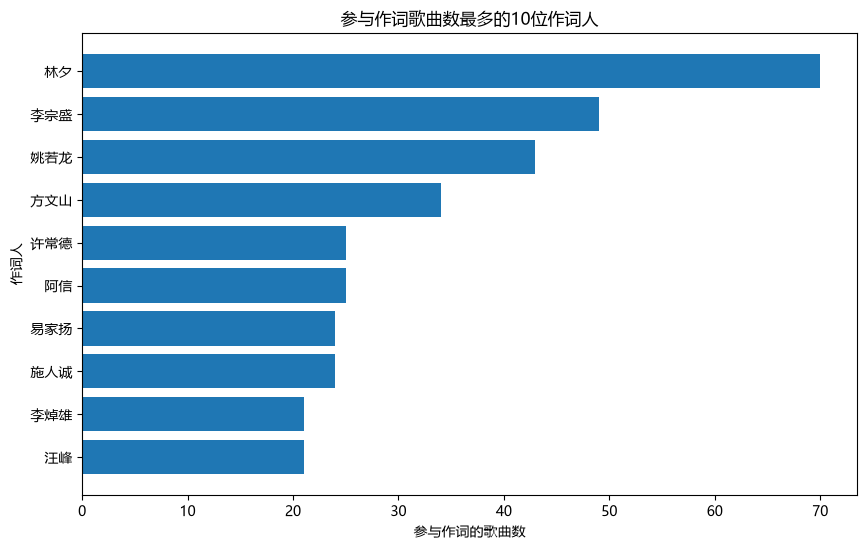

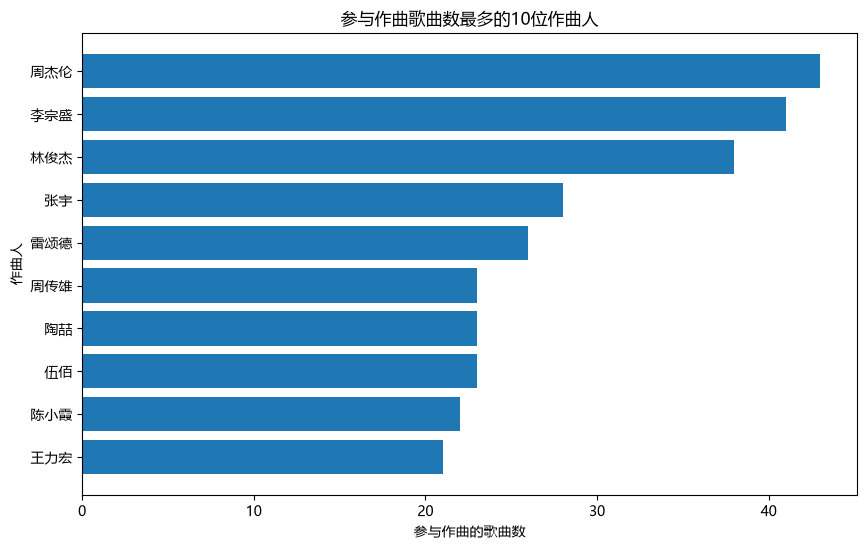

In [50]:
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

top10_lyricists = lyricist_counts.head(10).sort_values(by="song_count")

plt.figure(figsize=(10, 6))

plt.barh(
    top10_lyricists["creator"],
    top10_lyricists["song_count"]
)

plt.xlabel("参与作词的歌曲数")
plt.ylabel("作词人")
plt.title("参与作词歌曲数最多的10位作词人")


plt.show()


top10_composers = composer_counts.head(10).sort_values(by="song_count")


plt.figure(figsize=(10, 6))

plt.barh(
    top10_composers["creator"],
    top10_composers["song_count"]
)

plt.xlabel("参与作曲的歌曲数")
plt.ylabel("作曲人")
plt.title("参与作曲歌曲数最多的10位作曲人")


plt.show()

## 结论一：创作者参与歌曲数量分析

从作词人和作曲人参与歌曲数量的 Top 10 排名中，可以观察到以下特点。

### 1. 作词人头部差距较为明显

在作词人排名中，林夕参与作词的歌曲数约为 70 首，明显高于第二名李宗盛的约 49 首和第三名姚若龙的约 43 首。方文山约为 34 首，之后创作者的歌曲数大多集中在 20～25 首之间。

这说明在本次歌曲样本中，林夕的作词作品覆盖范围非常广，并且与其他头部作词人之间存在较明显的数量差距。除最头部的几位创作者外，其余作词人的参与歌曲数相对接近，呈现出“少数头部突出、其余创作者较为接近”的分布特点。

### 2. 作曲人头部排名相对更加均衡

在作曲人排名中，周杰伦约参与 43 首歌曲的作曲，李宗盛约为 41 首，林俊杰约为 38 首，前三名之间的差距并不大。其余作曲人的参与歌曲数大多位于 20～30 首之间。

与作词人排名相比，作曲人榜单没有出现某一位创作者远高于其他人的情况，头部作曲人的分布相对更加均衡。这表明在当前样本中，作曲工作虽然也集中在一批高频创作者身上，但头部作曲人之间的差距小于头部作词人之间的差距。

### 3. 作词人与作曲人的职业结构存在差异

作词人榜单中出现了林夕、姚若龙、方文山、许常德、易家扬、施人诚、李焯雄等以歌词创作为主要身份的创作者，说明歌词创作具有较明显的专业化特点。

相比之下，作曲人榜单中的周杰伦、李宗盛、林俊杰、张宇、周传雄、陶喆、伍佰和王力宏等，大多同时也是歌手。这说明在本次样本中，歌手亲自参与作曲的情况较为常见，作曲与演唱两个角色之间的联系可能比作词与演唱之间更加紧密。

这一现象为后续分析歌手的“自作词率”和“自作曲率”提供了依据：预计部分歌手的自作曲率会明显高于自作词率。

### 4. 当前图表反映的是排名，尚不能直接证明整体集中程度

Top 10 柱状图能够说明哪些创作者参与的歌曲较多，以及头部创作者之间的差距，但还不能单独证明全部创作资源是否高度集中。

例如，即使第一名参与了 70 首歌曲，如果全部样本中存在大量只创作一两首歌曲的创作者，那么整体分布可能非常分散；反之，如果前 10 位创作者覆盖了大量歌曲，才能说明创作资源具有明显的头部集中现象。

因此，下一步还需要计算：

- 前 10 位作词人覆盖的作词关系占比；
- 前 10 位作曲人覆盖的作曲关系占比；
- 作词人与作曲人的头部集中程度是否存在差异。

### 阶段性结论

综合两张图可以初步认为：本次样本中的作词人排名呈现出更明显的头部差距，林夕的参与歌曲数量显著领先；作曲人排名则相对均衡，周杰伦、李宗盛和林俊杰构成较接近的第一梯队。同时，作曲榜中出现了较多歌手型创作者，说明歌手参与作曲可能是华语流行歌曲创作中的重要现象，而歌词创作则表现出更强的专业分工特征。

需要注意的是，以上结论仅适用于本次爬取并成功提取作词、作曲信息的歌曲样本，不能直接代表整个音乐平台或全部华语音乐作品。

In [38]:
top10_lyricist_names = lyricist_counts.head(10)["creator"]
top10_composer_names = composer_counts.head(10)["creator"]


# 至少有一位Top 10作词人参与的歌曲比例
lyricist_song_coverage = (
    lyricist_long[
        lyricist_long["creator"].isin(top10_lyricist_names)
    ]["song_id"].nunique()
    / lyricist_long["song_id"].nunique()
)


# 至少有一位Top 10作曲人参与的歌曲比例
composer_song_coverage = (
    composer_long[
        composer_long["creator"].isin(top10_composer_names)
    ]["song_id"].nunique()
    / composer_long["song_id"].nunique()
)


print(f"前10位作词人覆盖的歌曲比例：{lyricist_song_coverage:.2%}")
print(f"前10位作曲人覆盖的歌曲比例：{composer_song_coverage:.2%}")

前10位作词人覆盖的歌曲比例：16.99%
前10位作曲人覆盖的歌曲比例：14.54%


### 分析结果

计算结果显示，前 10 位作词人覆盖了 16.99% 的歌曲，前 10 位作曲人覆盖了 14.54% 的歌曲。

结合创作者总数来看，前 10 位创作者仅占全部已识别创作者的约 1.1%，却分别参与了约六分之一的作词歌曲和七分之一的作曲歌曲。这说明歌曲创作并不是在大量创作者之间平均分布，而是存在较为明显的头部集中现象。

其中，作词人的 Top 10 歌曲覆盖率高于作曲人，表明本次样本中的作词资源比作曲资源更集中于少数高频创作者。这与此前的排名图相吻合：林夕等头部作词人的参与歌曲数量与后续创作者之间存在较明显差距，而头部作曲人之间的数量分布相对更加均衡。

不过，前 10 位创作者以外的约 890 位创作者仍然覆盖了超过 80% 的歌曲，因此当前分布不能简单描述为由少数人垄断。更准确的判断是：本次歌曲样本的创作者结构呈现出“头部显著集中、长尾创作者数量庞大”的特征。

## 第二板块：歌手自我创作程度分析

前面的分析关注创作资源是否集中在少数作词人和作曲人手中。本部分进一步研究演唱者是否参与了自己歌曲的创作，从而分析不同歌手在音乐生产中的角色差异。

本文分别定义两个指标：

- **自作词歌曲**：歌曲的演唱者姓名出现在该歌曲的作词人名单中；
- **自作曲歌曲**：歌曲的演唱者姓名出现在该歌曲的作曲人名单中。

在此基础上，计算每位歌手的自作词率和自作曲率：

自作词率 = 自己参与作词的歌曲数 ÷ 成功识别作词人的歌曲数

自作曲率 = 自己参与作曲的歌曲数 ÷ 成功识别作曲人的歌曲数

由于部分歌曲由多位歌手合作演唱，因此需要先将演唱者姓名拆分为列表，再分别判断每位演唱者是否出现在作词人或作曲人名单中。

需要说明的是，本分析采用姓名完全匹配。例如，演唱者为“五月天”、作词人为“阿信”时，不会被认定为自作词，因为当前数据中无法仅凭姓名直接判断乐队与成员之间的关系。

In [39]:
def split_singer_names(artist_name):
    """
    将演唱者字符串拆分为歌手列表。
    """

    if pd.isna(artist_name):
        return []

    text = str(artist_name).strip()

    names = re.split(
        r"\s*[&＆、]\s*",
        text
    )

    return names


songs["singers"] = songs["artist_name"].apply(split_singer_names)

display(
    songs[
        [
            "song_name",
            "artist_name",
            "singers",
        ]
    ].head(20)
)

,song_name,artist_name,singers
0,晴天,周杰伦,[周杰伦]
1,青花瓷,周杰伦,[周杰伦]
2,告白气球,周杰伦,[周杰伦]
3,那天下雨了,周杰伦,[周杰伦]
4,花海,周杰伦,[周杰伦]
5,稻香,周杰伦,[周杰伦]
6,七里香,周杰伦,[周杰伦]
7,红尘客栈,周杰伦,[周杰伦]
8,夜曲,周杰伦,[周杰伦]
9,搁浅,周杰伦,[周杰伦]


### 判断歌手是否参与歌曲创作

为了避免合作歌曲中的歌手被混在一起统计，本部分先将歌手列表展开，使每一行只对应一位歌手和一首歌曲。

随后分别判断该歌手的姓名是否出现在歌曲的作词人列表和作曲人列表中。若出现，则认为该歌手参与了相应的作词或作曲。

In [40]:
singer_song_long = songs[
    [
        "song_id",
        "song_name",
        "singers",
        "lyricists",
        "composers",
        "lyricist_raw",
        "composer_raw",
    ]
].copy()

singer_song_long=singer_song_long.explode("singers")

singer_song_long=singer_song_long.rename(columns={"singers":"singer"})

singer_song_long = singer_song_long[singer_song_long["singer"].notna()]

singer_song_long["self_lyricist"]=singer_song_long.apply(
    lambda row: row["singer"] in row["lyricists"],
    axis=1
)

singer_song_long["self_composer"] = singer_song_long.apply(
    lambda row: row["singer"] in row["composers"],
    axis=1
)


display( 
    singer_song_long[
        [
            "song_name",
            "singer",
            "lyricists",
            "self_lyricist",
            "composers",
            "self_composer",
        ]
    ].head(30)
)



,song_name,singer,lyricists,self_lyricist,composers,self_composer
0,晴天,周杰伦,[周杰伦],True,[周杰伦],True
1,青花瓷,周杰伦,[方文山],False,[周杰伦],True
2,告白气球,周杰伦,[方文山],False,[周杰伦],True
3,那天下雨了,周杰伦,[周杰伦],True,[周杰伦],True
4,花海,周杰伦,"[古小力, 黄淩嘉]",False,[周杰伦],True
5,稻香,周杰伦,[周杰伦],True,[周杰伦],True
6,七里香,周杰伦,[方文山],False,[周杰伦],True
7,红尘客栈,周杰伦,[方文山],False,[周杰伦],True
8,夜曲,周杰伦,[方文山],False,[周杰伦],True
9,搁浅,周杰伦,[宋健彰],False,[周杰伦],True


### 计算每位歌手的自我创作比例

在得到每首歌曲中“歌手是否参与作词、作曲”的判断结果后，接下来按照歌手进行分组统计。

为了避免创作者信息缺失影响结果，自作词率只使用成功识别出作词人的歌曲作为分母，自作曲率只使用成功识别出作曲人的歌曲作为分母。

同时，为减少歌曲数量过少导致的偶然性，后续可视化仅保留至少有 5 首歌曲成功识别出作词、作曲信息的歌手。

In [41]:
singer_song_long["lyric_known"] = (
    singer_song_long["lyricist_raw"].notna()
)

singer_song_long["composer_known"] = (
    singer_song_long["composer_raw"].notna()
)

grouped=singer_song_long.groupby("singer")
singer_stats=grouped.agg(
    total_songs=("song_id", "nunique"),
    lyric_known=("lyric_known", "sum"),
    composer_known=("composer_known", "sum"),
    self_lyric_songs=("self_lyricist", "sum"),
    self_compose_songs=("self_composer", "sum"),
).reset_index()

singer_stats["self_lyric_rate"] = (
    singer_stats["self_lyric_songs"]
    / singer_stats["lyric_known"]
)

singer_stats["self_compose_rate"] = (
    singer_stats["self_compose_songs"]
    / singer_stats["composer_known"]
)

singer_stats_valid = singer_stats[
    (singer_stats["lyric_known"] >= 5)
    & (singer_stats["composer_known"] >= 5)
].copy()

singer_stats_valid = singer_stats_valid.sort_values(
    by="total_songs",
    ascending=False
)

display(singer_stats_valid.head(20))


,singer,total_songs,lyric_known,composer_known,self_lyric_songs,self_compose_songs,self_lyric_rate,self_compose_rate
139,唐伯虎Annie,33,22,21,0,0,0.000000,0.000000
191,张韶涵,27,26,26,0,0,0.000000,0.000000
135,周杰伦,25,25,25,4,25,0.160000,1.000000
173,张信哲,25,23,23,0,0,0.000000,0.000000
86,任贤齐,25,23,23,6,7,0.260870,0.304348
307,莫文蔚,24,23,23,0,0,0.000000,0.000000
266,王力宏,23,22,22,13,18,0.590909,0.818182
270,王杰,22,22,22,4,6,0.181818,0.272727
233,林俊杰,22,22,22,0,21,0.000000,0.954545
351,陈奕迅,22,20,21,0,0,0.000000,0.000000


### 歌手自作词率与自作曲率的关系

为了比较不同歌手参与作词和作曲的程度，本文绘制自作词率与自作曲率散点图。

图中每个点代表一位歌手，横坐标表示自作词率，纵坐标表示自作曲率，点的大小表示该歌手在样本中的歌曲数量。

图中的虚线表示自作词率与自作曲率相等。位于虚线上方的歌手，自作曲率高于自作词率；位于虚线下方的歌手，自作词率高于自作曲率。

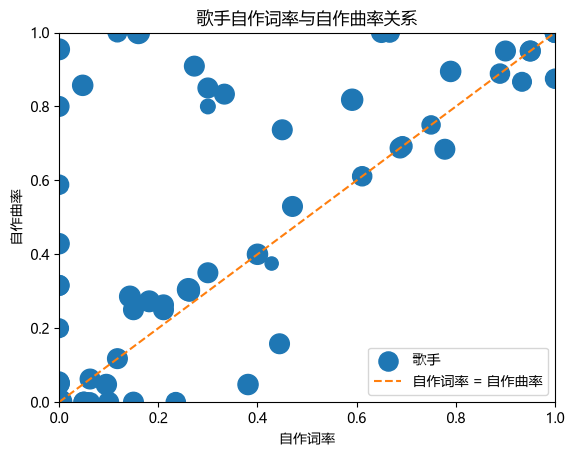

In [52]:

x = singer_stats_valid["self_lyric_rate"]
y = singer_stats_valid["self_compose_rate"]

point_size = singer_stats_valid["total_songs"] * 10

plt.scatter(
    x,
    y,
    s=point_size,
    marker="o",
    color="C0",
    label="歌手"
)


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="C1",
    label="自作词率 = 自作曲率"
)

plt.title("歌手自作词率与自作曲率关系")
plt.xlabel("自作词率")
plt.ylabel("自作曲率")


plt.xlim(0, 1)
plt.ylim(0, 1)


plt.xticks(np.arange(0, 1.1, 0.2))
plt.yticks(np.arange(0, 1.1, 0.2))


plt.legend()

plt.show()

In [ ]:

singer_stats_valid = singer_stats_valid.copy()


valid_singer_count = len(singer_stats_valid)


# 总体自作词率
overall_self_lyric_rate = (
    singer_stats_valid["self_lyric_songs"].sum()
    / singer_stats_valid["lyric_known"].sum()
)


# 总体自作曲率
overall_self_compose_rate = (
    singer_stats_valid["self_compose_songs"].sum()
    / singer_stats_valid["composer_known"].sum()
)


# 各歌手自作词率、自作曲率的中位数
median_self_lyric_rate = (
    singer_stats_valid["self_lyric_rate"].median()
)

median_self_compose_rate = (
    singer_stats_valid["self_compose_rate"].median()
)


def compare_creation_rate(row):
    lyric_rate = row["self_lyric_rate"]
    compose_rate = row["self_compose_rate"]

    if lyric_rate == 0 and compose_rate == 0:
        return "两项均为0"

    difference = compose_rate - lyric_rate

    if difference > 0.05:
        return "自作曲率更高"

    elif difference < -0.05:
        return "自作词率更高"

    else:
        return "两者非零且接近"


singer_stats_valid["rate_relation"] = (
    singer_stats_valid.apply(
        compare_creation_rate,
        axis=1
    )
)



def classify_singer(row):
    lyric_rate = row["self_lyric_rate"]
    compose_rate = row["self_compose_rate"]

    if lyric_rate >= 0.5 and compose_rate >= 0.5:
        return "综合唱作型"

    elif lyric_rate < 0.5 and compose_rate >= 0.5:
        return "作曲主导型"

    elif lyric_rate >= 0.5 and compose_rate < 0.5:
        return "作词主导型"

    else:
        return "演唱主导型"


singer_stats_valid["creator_type"] = (
    singer_stats_valid.apply(
        classify_singer,
        axis=1
    )
)

# 统计作词、作曲倾向的人数
relation_counts = (
    singer_stats_valid["rate_relation"]
    .value_counts()
)


# 统计四种创作类型的人数
type_counts = (
    singer_stats_valid["creator_type"]
    .value_counts()
)



top10_singers = (
    singer_stats_valid
    .sort_values(
        by="total_songs",
        ascending=False
    )
    .head(10)
)


print("有效歌手总数：", valid_singer_count)

print(
    f"\n总体自作词率："
    f"{overall_self_lyric_rate:.2%}"
)

print(
    f"总体自作曲率："
    f"{overall_self_compose_rate:.2%}"
)

print(
    f"歌手自作词率中位数："
    f"{median_self_lyric_rate:.2%}"
)

print(
    f"歌手自作曲率中位数："
    f"{median_self_compose_rate:.2%}"
)


print("\n作词与作曲倾向人数：")
display(relation_counts)


print("\n四种创作类型人数：")
display(type_counts)


print("\n歌曲数量最多的10位歌手：")
display(
    top10_singers[
        [
            "singer",
            "total_songs",
            "self_lyric_songs",
            "self_compose_songs",
            "self_lyric_rate",
            "self_compose_rate",
            "rate_relation",
            "creator_type",
        ]
    ]
)

有效歌手总数： 126

总体自作词率：18.25%
总体自作曲率：25.72%
歌手自作词率中位数：0.00%
歌手自作曲率中位数：0.00%

作词与作曲倾向人数：


rate_relation
两项均为0      64
自作曲率更高     28
两者非零且接近    23
自作词率更高     11
Name: count, dtype: int64


四种创作类型人数：


creator_type
演唱主导型    96
综合唱作型    18
作曲主导型    12
Name: count, dtype: int64


歌曲数量最多的10位歌手：


,singer,total_songs,self_lyric_songs,self_compose_songs,self_lyric_rate,self_compose_rate,rate_relation,creator_type
139,唐伯虎Annie,33,0,0,0.000000,0.000000,两项均为0,演唱主导型
191,张韶涵,27,0,0,0.000000,0.000000,两项均为0,演唱主导型
135,周杰伦,25,4,25,0.160000,1.000000,自作曲率更高,作曲主导型
173,张信哲,25,0,0,0.000000,0.000000,两项均为0,演唱主导型
86,任贤齐,25,6,7,0.260870,0.304348,两者非零且接近,演唱主导型
307,莫文蔚,24,0,0,0.000000,0.000000,两项均为0,演唱主导型
266,王力宏,23,13,18,0.590909,0.818182,自作曲率更高,综合唱作型
270,王杰,22,4,6,0.181818,0.272727,自作曲率更高,演唱主导型
233,林俊杰,22,0,21,0.000000,0.954545,自作曲率更高,作曲主导型
351,陈奕迅,22,0,0,0.000000,0.000000,两项均为0,演唱主导型


## 结论二：歌手自我创作程度分析结论

本部分选取了作词信息和作曲信息均至少有 5 首有效歌曲的歌手，共计 126 位。通过比较歌手在自身歌曲中的作词、作曲参与情况，可以观察不同歌手在音乐生产中的角色差异。

#### 1. 歌手参与作曲的程度整体高于参与作词的程度

在全部有效歌曲记录中，歌手总体自作词率为 18.25%，总体自作曲率为 25.72%。自作曲率比自作词率高出 7.47 个百分点，说明在本次样本中，歌手参与自己歌曲作曲的现象比参与作词更加常见。

在 126 位歌手中，有 28 位歌手的自作曲率明显高于自作词率，占有效歌手的 22.22%；自作词率明显更高的歌手只有 11 位，占 8.73%。自作曲率占优的歌手数量约为自作词率占优歌手的 2.5 倍，进一步表明歌手更倾向于参与旋律创作，而歌词创作更可能由专业作词人承担。

这一结果也与前面的创作者排名相互印证：作词人榜单中以林夕、姚若龙、方文山等专业作词人为主，而作曲人榜单中则出现了周杰伦、林俊杰、李宗盛、王力宏等大量歌手型创作者。

#### 2. 多数歌手在当前样本中主要承担演唱角色

126 位有效歌手中，有 96 位被划分为“演唱主导型”，占比约为 76.19%。这类歌手的自作词率和自作曲率均低于 50%，说明在当前样本中，大部分歌手的主要职责仍然是演唱，作词和作曲工作更多由其他创作者完成。

同时，有 64 位歌手的自作词率和自作曲率均为 0，占全部有效歌手的约 50.79%。这也是歌手自作词率和自作曲率中位数均为 0 的主要原因。也就是说，从“典型歌手”的角度看，至少一半的歌手没有以完全相同的姓名出现在自己歌曲的作词或作曲名单中。

但是，这并不意味着这些歌手完全不具备创作能力。该结果只能说明，在本次收集并成功识别创作者信息的歌曲中，没有发现其以相同姓名参与词曲创作。

#### 3. 少数高参与度歌手贡献了较多自我创作歌曲

虽然多数歌手的自创率较低，但样本中仍然存在一批词曲参与程度很高的歌手。126 位歌手中，有 18 位属于“综合唱作型”，占比约为 14.29%；另有 12 位属于“作曲主导型”，占比约为 9.52%。

歌曲数量较多的歌手中，周杰伦的自作曲率达到 100%，但自作词率为 16%，表现出明显的作曲主导特征；林俊杰的自作曲率约为 95.45%，自作词率为 0，同样表现出很强的作曲参与特征。

王力宏的自作词率约为 59.09%，自作曲率约为 81.82%，两项比例均超过 50%，属于较典型的综合唱作型歌手。相比之下，张韶涵、张信哲、莫文蔚等歌手在当前样本中的两项自创率均为 0，更偏向演唱主导型。

这表明歌手群体内部存在明显分化：一部分歌手主要负责演唱，另一部分歌手则深度参与歌曲创作，甚至承担绝大部分作曲工作。

#### 4. 自作词与自作曲是两种相对独立的创作行为

在自作词率和自作曲率散点图中，许多点明显偏离“自作词率等于自作曲率”的参考线。除 64 位两项均为 0 的歌手外，有 28 位歌手自作曲率明显更高，11 位歌手自作词率明显更高，23 位歌手两项非零且差距较小。

这说明歌手参与作词和参与作曲并不一定同步。部分歌手可能长期参与旋律创作，但很少直接作词；也有部分歌手更擅长文字表达，而较少参与作曲。因此，不能仅使用一个笼统的“创作型歌手”指标评价歌手，而应分别考察其作词参与度和作曲参与度。

#### 阶段性结论

综合以上结果，本次样本中的歌手创作结构呈现出“多数以演唱为主、少数深度参与创作”的特点。大部分歌手的自作词率和自作曲率较低，但少数唱作型歌手贡献了大量自我创作歌曲。

同时，歌手参与作曲的程度整体高于参与作词的程度，说明流行音乐生产中可能存在较明显的专业分工：部分歌手负责演唱和旋律创作，而歌词创作则更多依赖专业作词人。

需要注意的是，本分析采用歌手姓名与创作者姓名完全匹配的方法。艺名与本名不同、中英文姓名不同，以及“乐队名称—乐队成员姓名”等情况，可能导致部分歌手的自作词率和自作曲率被低估。因此，本结论仅适用于当前姓名匹配规则和本次爬取到的歌曲样本。

## 第三板块：歌手与创作者的稳定合作关系分析

前两部分分别研究了创作资源的集中程度以及歌手参与自身歌曲创作的情况。本部分进一步关注歌手与外部创作者之间的合作关系。

如果某位歌手与同一位作词人或作曲人在多首歌曲中重复合作，说明这种创作组合并非偶然，而可能形成了相对稳定的合作搭档。

因此，本部分首先构造“歌手—作词人”和“歌手—作曲人”关系表，再统计每组搭档共同参与的不同歌曲数量，并据此分析音乐创作中的稳定合作模式。

In [44]:
singer_lyricist_rows = []
singer_composer_rows = []


for _, row in songs.iterrows():

    for singer in row["singers"]:

        for lyricist in row["lyricists"]:
            singer_lyricist_rows.append(
                {
                    "song_id": row["song_id"],
                    "song_name": row["song_name"],
                    "singer": singer,
                    "creator": lyricist,
                }
            )

        for composer in row["composers"]:
            singer_composer_rows.append(
                {
                    "song_id": row["song_id"],
                    "song_name": row["song_name"],
                    "singer": singer,
                    "creator": composer,
                }
            )
singer_lyricist = pd.DataFrame(
    singer_lyricist_rows
)
singer_composer = pd.DataFrame(
    singer_composer_rows
)


print(
    "歌手—作词人关系数：",
    len(singer_lyricist)
)
print(
    "歌手—作曲人关系数：",
    len(singer_composer)
)


display(singer_lyricist.head(20))
display(singer_composer.head(20))

歌手—作词人关系数： 3488
歌手—作曲人关系数： 3549


,song_id,song_name,singer,creator
0,228908,晴天,周杰伦,周杰伦
1,324244,青花瓷,周杰伦,方文山
2,7149583,告白气球,周杰伦,方文山
3,550531860,那天下雨了,周杰伦,周杰伦
4,440615,花海,周杰伦,古小力
5,440615,花海,周杰伦,黄淩嘉
6,440613,稻香,周杰伦,周杰伦
7,94237,七里香,周杰伦,方文山
8,3195905,红尘客栈,周杰伦,方文山
9,118980,夜曲,周杰伦,方文山


,song_id,song_name,singer,creator
0,228908,晴天,周杰伦,周杰伦
1,324244,青花瓷,周杰伦,周杰伦
2,7149583,告白气球,周杰伦,周杰伦
3,550531860,那天下雨了,周杰伦,周杰伦
4,440615,花海,周杰伦,周杰伦
5,440613,稻香,周杰伦,周杰伦
6,94237,七里香,周杰伦,周杰伦
7,3195905,红尘客栈,周杰伦,周杰伦
8,118980,夜曲,周杰伦,周杰伦
9,94239,搁浅,周杰伦,周杰伦


### 统计歌手与外部创作者的合作次数

一位歌手和同一位作词人或作曲人可能在多首歌曲中反复合作。为了衡量这种合作关系的稳定程度，本部分按照“歌手—创作者”组合进行分组，并统计每组搭档共同参与的不同歌曲数量。

由于歌手本人参与创作的情况已经在上一部分进行了分析，本部分排除歌手姓名与创作者姓名完全相同的记录，重点考察歌手与外部作词人、作曲人之间的合作关系。

In [ ]:
# 1. 统计每组“歌手—作词人”合作的歌曲数
lyricist_pairs = (
    singer_lyricist
    .groupby(["singer", "creator"])["song_id"]
    .nunique()
    .reset_index(name="song_count")
    .sort_values(
        by="song_count",
        ascending=False
    )
)

# 2. 统计每组“歌手—作曲人”合作的歌曲数
composer_pairs = (
    singer_composer
    .groupby(["singer", "creator"])["song_id"]
    .nunique()
    .reset_index(name="song_count")
    .sort_values(
        by="song_count",
        ascending=False
    )
)

# 3. 排除歌手本人就是创作者的记录
external_lyricist_pairs = lyricist_pairs[
    lyricist_pairs["singer"]
    != lyricist_pairs["creator"]
].copy()

external_composer_pairs = composer_pairs[
    composer_pairs["singer"]
    != composer_pairs["creator"]
].copy()

# 4. 查看合作次数最多的搭档

print("合作次数最多的歌手—作词人搭档：")

display(
    external_lyricist_pairs.head(20)
)


print("合作次数最多的歌手—作曲人搭档：")

display(
    external_composer_pairs.head(20)
)

合作次数最多的歌手—作词人搭档：


,singer,creator,song_count
89,BIGBANG,G-DRAGON,20
273,Justin Bieber,Carter Lang,19
479,五月天,阿信,19
1465,老板,任夏,17
1842,陶喆,娃娃,16
277,Justin Bieber,Dylan Wiggins,16
176,F.I.R.飞儿乐团,谢宥慧,15
690,周杰伦,方文山,15
232,Imagine Dragons,Dan Reynolds,15
888,张宇,十一郎,15


合作次数最多的歌手—作曲人搭档：


,singer,creator,song_count
307,Justin Bieber,Carter Lang,19
109,BIGBANG,G-DRAGON,19
311,Justin Bieber,Dylan Wiggins,16
104,BEYOND,黄家驹,16
616,刘珂矣,百慕三石,15
314,Justin Bieber,Jackson Lee Morgan,15
262,Imagine Dragons,Dan Reynolds,15
312,Justin Bieber,Eddie Benjamin,15
143,China Blue,伍佰,15
1506,老板,曲多美,14


### 计算歌手对核心创作者的合作依赖程度

仅比较合作歌曲数量，容易受到歌手样本总量的影响。因此，本部分进一步计算每组搭档的合作占比。

作词合作占比定义为：

合作作词歌曲数 ÷ 该歌手成功识别作词信息的歌曲数

作曲合作占比定义为：

合作作曲歌曲数 ÷ 该歌手成功识别作曲信息的歌曲数

合作占比越高，说明该歌手的作品越集中于某位固定创作者。需要注意的是，当前仅排除了歌手姓名与创作者姓名完全相同的记录，因此乐队名称与成员姓名不同的情况仍会保留。

In [46]:
# 1. 准备每位歌手的有效作词、作曲歌曲数

singer_known_counts = singer_stats[
    [
        "singer",
        "lyric_known",
        "composer_known",
    ]
].copy()

# 2. 给“歌手—作词人”关系增加有效歌曲数

external_lyricist_pairs = external_lyricist_pairs.merge(
    singer_known_counts[
        [
            "singer",
            "lyric_known",
        ]
    ],
    on="singer",
    how="left"
)


external_lyricist_pairs["cooperation_rate"] = (
    external_lyricist_pairs["song_count"]
    / external_lyricist_pairs["lyric_known"]
)

# 3. 给“歌手—作曲人”关系增加有效歌曲数

external_composer_pairs = external_composer_pairs.merge(
    singer_known_counts[
        [
            "singer",
            "composer_known",
        ]
    ],
    on="singer",
    how="left"
)


# 作曲合作占比
external_composer_pairs["cooperation_rate"] = (
    external_composer_pairs["song_count"]
    / external_composer_pairs["composer_known"]
)

# 4. 找出每位歌手合作次数最多的一位创作者


top_lyricist_partner = (
    external_lyricist_pairs
    .sort_values(
        by=["singer", "song_count"],
        ascending=[True, False]
    )
    .groupby("singer")
    .head(1)
)


top_composer_partner = (
    external_composer_pairs
    .sort_values(
        by=["singer", "song_count"],
        ascending=[True, False]
    )
    .groupby("singer")
    .head(1)
)

# 5. 只保留有效歌曲不少于5首的歌手

top_lyricist_partner = top_lyricist_partner[
    top_lyricist_partner["lyric_known"] >= 5
].copy()

top_composer_partner = top_composer_partner[
    top_composer_partner["composer_known"] >= 5
].copy()

# 6. 查看合作占比最高的核心搭档

top_lyricist_partner = top_lyricist_partner.sort_values(
    by="cooperation_rate",
    ascending=False
)

top_composer_partner = top_composer_partner.sort_values(
    by="cooperation_rate",
    ascending=False
)


print("核心作词搭档合作占比最高的歌手：")

display(
    top_lyricist_partner[
        [
            "singer",
            "creator",
            "song_count",
            "lyric_known",
            "cooperation_rate",
        ]
    ].head(20)
)


print("核心作曲搭档合作占比最高的歌手：")

display(
    top_composer_partner[
        [
            "singer",
            "creator",
            "song_count",
            "composer_known",
            "cooperation_rate",
        ]
    ].head(20)
)

核心作词搭档合作占比最高的歌手：


,singer,creator,song_count,lyric_known,cooperation_rate
0,BIGBANG,G-DRAGON,20,20,1.000000
1,Justin Bieber,Carter Lang,19,20,0.950000
2,五月天,阿信,19,20,0.950000
8,Imagine Dragons,Dan Reynolds,15,16,0.937500
9,张宇,十一郎,15,17,0.882353
3,老板,任夏,17,20,0.850000
13,China Blue,伍佰,14,17,0.823529
4,陶喆,娃娃,16,20,0.800000
78,飞轮海,张家玮,4,5,0.800000
6,F.I.R.飞儿乐团,谢宥慧,15,20,0.750000


核心作曲搭档合作占比最高的歌手：


,singer,creator,song_count,composer_known,cooperation_rate
3,BEYOND,黄家驹,16,16,1.000000
42,张雨生,陈志远,5,5,1.000000
1,BIGBANG,G-DRAGON,19,20,0.950000
0,Justin Bieber,Carter Lang,19,20,0.950000
4,刘珂矣,百慕三石,15,16,0.937500
6,Imagine Dragons,Dan Reynolds,15,16,0.937500
8,China Blue,伍佰,15,17,0.882353
49,甄妮,顾嘉煇,5,6,0.833333
77,飞轮海,林俊杰,4,5,0.800000
41,王忻辰,IN-K,5,7,0.714286


In [47]:
# 作词核心搭档达到不同合作程度的歌手数量
lyric_rate_50 = (
    top_lyricist_partner["cooperation_rate"] >= 0.5
).sum()

lyric_rate_75 = (
    top_lyricist_partner["cooperation_rate"] >= 0.75
).sum()

# 作曲核心搭档达到不同合作程度的歌手数量
compose_rate_50 = (
    top_composer_partner["cooperation_rate"] >= 0.5
).sum()

compose_rate_75 = (
    top_composer_partner["cooperation_rate"] >= 0.75
).sum()


print("核心作词搭档合作占比不低于50%的歌手数：", lyric_rate_50)
print("核心作词搭档合作占比不低于75%的歌手数：", lyric_rate_75)

print("核心作曲搭档合作占比不低于50%的歌手数：", compose_rate_50)
print("核心作曲搭档合作占比不低于75%的歌手数：", compose_rate_75)

核心作词搭档合作占比不低于50%的歌手数： 21
核心作词搭档合作占比不低于75%的歌手数： 10
核心作曲搭档合作占比不低于50%的歌手数： 17
核心作曲搭档合作占比不低于75%的歌手数： 9


存在有效作词搭档的歌手数： 125
存在有效作曲搭档的歌手数： 123
核心作词搭档合作占比不低于50%的歌手比例：16.80%
核心作词搭档合作占比不低于75%的歌手比例：8.00%
核心作曲搭档合作占比不低于50%的歌手比例：13.82%
核心作曲搭档合作占比不低于75%的歌手比例：7.32%


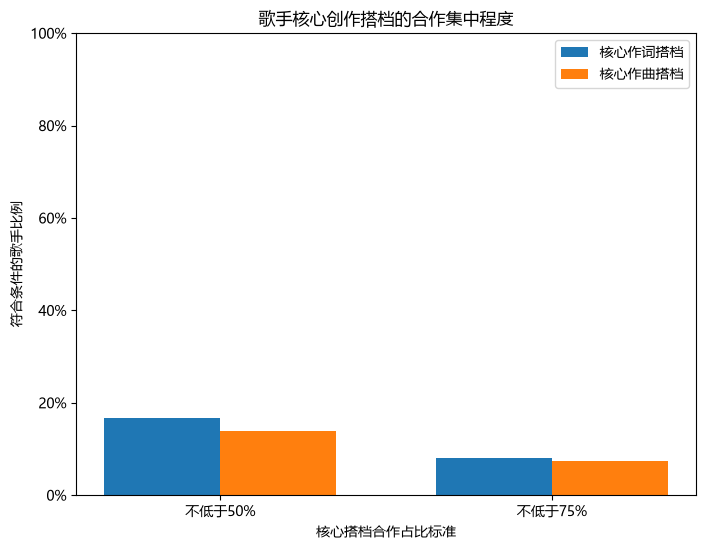

In [48]:
lyric_partner_total = len(top_lyricist_partner)
composer_partner_total = len(top_composer_partner)


lyric_rate_50_ratio = lyric_rate_50 / lyric_partner_total
lyric_rate_75_ratio = lyric_rate_75 / lyric_partner_total

compose_rate_50_ratio = compose_rate_50 / composer_partner_total
compose_rate_75_ratio = compose_rate_75 / composer_partner_total


print("存在有效作词搭档的歌手数：", lyric_partner_total)
print("存在有效作曲搭档的歌手数：", composer_partner_total)

print(
    f"核心作词搭档合作占比不低于50%的歌手比例："
    f"{lyric_rate_50_ratio:.2%}"
)

print(
    f"核心作词搭档合作占比不低于75%的歌手比例："
    f"{lyric_rate_75_ratio:.2%}"
)

print(
    f"核心作曲搭档合作占比不低于50%的歌手比例："
    f"{compose_rate_50_ratio:.2%}"
)

print(
    f"核心作曲搭档合作占比不低于75%的歌手比例："
    f"{compose_rate_75_ratio:.2%}"
)

labels = ["不低于50%", "不低于75%"]

lyric_values = [
    lyric_rate_50_ratio,
    lyric_rate_75_ratio,
]

composer_values = [
    compose_rate_50_ratio,
    compose_rate_75_ratio,
]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 6))

plt.bar(
    x - width / 2,
    lyric_values,
    width=width,
    label="核心作词搭档"
)

plt.bar(
    x + width / 2,
    composer_values,
    width=width,
    label="核心作曲搭档"
)

plt.title("歌手核心创作搭档的合作集中程度")
plt.xlabel("核心搭档合作占比标准")
plt.ylabel("符合条件的歌手比例")

plt.xticks(x, labels)

plt.ylim(0, 1)

plt.yticks(
    np.arange(0, 1.1, 0.2),
    ["0%", "20%", "40%", "60%", "80%", "100%"]
)

plt.legend()
plt.show()

## 结论三：歌手与创作者稳定合作关系分析结论

本部分针对歌手与非同名创作者之间的合作关系进行分析。对于每位歌手，选取其合作歌曲数量最多的一位作词人和一位作曲人作为“核心创作搭档”，并计算该搭档参与歌曲数占歌手有效歌曲数的比例。

本次分析中，共有 125 位歌手存在有效作词搭档，123 位歌手存在有效作曲搭档。

#### 1. 稳定创作搭档确实存在，但主要集中在少数歌手中

在 125 位存在有效作词搭档的歌手中，有 21 位歌手的核心作词搭档参与了其不少于 50% 的歌曲，占比为 16.80%；其中有 10 位歌手的核心作词搭档参与比例不低于 75%，占比为 8.00%。

在 123 位存在有效作曲搭档的歌手中，有 17 位歌手的核心作曲搭档参与了其不少于 50% 的歌曲，占比为 13.82%；其中有 9 位歌手的核心作曲搭档参与比例不低于 75%，占比为 7.32%。

这说明音乐创作中确实存在长期、稳定的核心合作关系，但这种高度集中的合作模式并不是所有歌手的普遍状态。大部分歌手并没有将超过一半的作品集中交给同一位作词人或作曲人，创作来源仍然具有一定多样性。

因此，本次样本所呈现的并不是“所有歌手都有固定搭档”，而是“少数歌手与特定创作者形成了非常稳定的长期合作关系”。

#### 2. 固定作词搭档现象略强于固定作曲搭档

核心作词搭档合作占比不低于 50% 的歌手比例为 16.80%，比核心作曲搭档的 13.82% 高 2.98 个百分点。

在更严格的 75% 标准下，核心作词搭档对应比例为 8.00%，核心作曲搭档为 7.32%，二者差距缩小到 0.68 个百分点。

这说明固定作词搭档的现象整体上略强于固定作曲搭档，但差异并不悬殊。部分歌手可能长期与特定作词人合作，以保持歌词主题、语言风格和个人形象的一致性；而在作曲方面，歌手可能与更多不同创作者合作，或者由歌手本人参与作曲。

这一结果也与前面的创作者分析相呼应：作词领域存在较明显的专业化分工，一些歌手会长期依赖固定的专业作词人。

#### 3. 部分歌手与核心作词人形成了高度稳定的合作关系

在作词合作关系中，可以观察到多组合作次数较多、合作占比较高的组合。

例如：

- 五月天与阿信合作 19 首，占有效作词歌曲的 95%；
- 张宇与十一郎合作 15 首，占比约为 88.24%；
- 老板与任夏合作 17 首，占比为 85%；
- 周杰伦与方文山合作 15 首，占比为 60%；
- 周传雄与陈信荣合作 13 首，占比约为 61.90%。

其中，周杰伦与方文山、张宇与十一郎等组合属于较典型的长期词曲合作关系。核心作词人持续参与同一歌手的大量歌曲，有助于形成相对统一的歌词表达、叙事主题和音乐形象。

例如，周杰伦与方文山的合作占比虽然不是最高，但共同合作歌曲数达到 15 首，说明这一关系不仅比例较高，而且具有较大的样本数量，其稳定性比只合作三四首但占比很高的组合更有说服力。

#### 4. 核心作曲搭档同样具有明显的集中现象

作曲合作关系中也存在若干高度集中的组合，例如：

- BEYOND 与黄家驹合作 16 首，占比为 100%；
- Justin Bieber 与 Carter Lang 合作 19 首，占比为 95%；
- 刘珂矣与百慕三石合作 15 首，占比约为 93.75%；
- Imagine Dragons 与 Dan Reynolds 合作 15 首，占比约为 93.75%；
- China Blue 与伍佰合作 15 首，占比约为 88.24%；
- 五月天与阿信合作 13 首，占比为 65%。

这些结果说明，部分歌手或组合的旋律创作长期集中于少数核心成员或固定作曲人。对于这些歌手而言，核心作曲者可能在其音乐风格形成过程中承担了重要作用。

不过，作曲搭档高度集中的歌手只占全部有效歌手的一小部分。更多歌手仍然会与多位作曲人合作，说明歌曲旋律来源整体上仍具有一定多样性。

#### 5. 稳定合作关系包括两种不同模式

当前分析只排除了“歌手姓名与创作者姓名完全相同”的记录，因此结果中的核心搭档实际上包含两种不同模式。

第一种是歌手与外部专业创作者之间的长期合作，例如：

- 周杰伦与方文山；
- 张宇与十一郎；
- 周传雄与陈信荣。

第二种是乐队或组合与内部核心成员之间的创作关系，例如：

- 五月天与阿信；
- BEYOND 与黄家驹；
- BIGBANG 与 G-DRAGON；
- Imagine Dragons 与 Dan Reynolds；
- China Blue 与伍佰。

第二种关系并不属于普通意义上的“外部合作”，而是组合内部成员承担主要创作工作的表现。因此，更准确的说法是，这些关系共同反映了音乐作品背后的“核心创作者结构”。

这也说明歌手或组合保持创作风格稳定的方式并不相同：有些依靠固定的外部词曲作者，有些则依靠组合内部的核心创作成员。



### 阶段性结论

本次分析表明，歌手与创作者之间确实存在稳定合作关系，但高度依赖单一核心搭档的歌手只占少数。

核心作词搭档合作占比不低于 50% 的歌手占 16.80%，核心作曲搭档对应比例为 13.82%；合作占比不低于 75% 的歌手比例则分别为 8.00% 和 7.32%。这说明大多数歌手的作品仍由多位创作者共同参与，但少数歌手已经形成了非常稳定的核心创作组合。

从具体关系来看，稳定合作主要表现为两种模式：一是歌手与外部专业作词人、作曲人之间的长期合作；二是乐队或组合内部由核心成员长期承担创作工作。前者体现了音乐生产中的专业分工，后者则体现了组合内部稳定的创作核心。

需要注意的是，本分析基于当前爬取并成功识别创作者信息的歌曲样本，同时采用姓名完全匹配的方法。艺名、本名、中英文名称及组合成员关系等因素可能影响合作关系的识别，因此结论仅适用于当前样本和数据处理规则。

## 总体结论与分析局限

本次分析从歌词署名中提取作词人和作曲人信息，并围绕创作者集中程度、歌手自我创作程度以及稳定合作关系展开研究。

主要结论如下：

1. 创作者分布呈现“头部显著集中、长尾创作者数量庞大”的特点；
2. 多数歌手主要承担演唱角色，但少数歌手深度参与词曲创作，并且歌手参与作曲的程度整体高于参与作词；
3. 少数歌手与特定创作者形成了高度稳定的核心合作关系，但多数歌手的创作来源仍然较为多样。

本分析仍存在一定局限。首先，部分歌曲未能成功提取作词、作曲信息；其次，姓名匹配采用完全匹配方法，艺名、本名、中英文名称及乐队成员关系可能造成重复统计或识别不足；最后，样本来源和爬取关键词会影响歌手及歌曲的分布，因此结论仅适用于当前样本。